# Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on three datasets:

1. **Adult Census Income** (`adult.csv`) — predicting whether income exceeds $50K/yr
2. **Hotel Booking Demand** (`hotel_booking.csv`) — hotel reservation and cancellation data
3. **Loan Prediction** (`loan-train.csv`) — loan approval status data

Each section covers: data loading, structure/dtypes, missing values, summary statistics,
distributions of key variables, and relationships with the target variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

%matplotlib inline

---
# 1. Adult Census Income Dataset (`adult.csv`)

## 1.1 Load & Basic Structure

In [2]:
adult = pd.read_csv("adult.csv")
print("Shape:", adult.shape)
adult.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
adult.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [4]:
# Replace '?' placeholders with NaN (common in this dataset) and re-check
adult = adult.replace("?", np.nan)
adult.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,46043,8,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
educational-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46033,14,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.2 Missing Values

occupation        2809
workclass         2799
native-country     857
dtype: int64


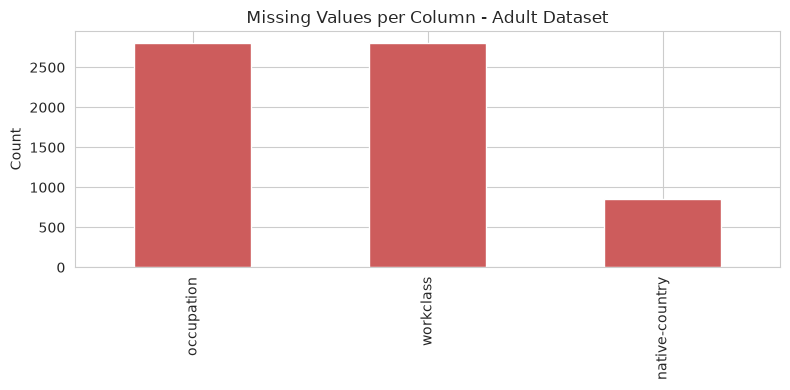

In [5]:
missing = adult.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

if len(missing) > 0:
    plt.figure(figsize=(8, 4))
    missing.plot(kind="bar", color="indianred")
    plt.title("Missing Values per Column - Adult Dataset")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

## 1.3 Target Variable: `income`

income
<=50K    37155
>50K     11687
Name: count, dtype: int64
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


/tmp/ipykernel_389/2995816504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=adult, x="income", palette="Set2")


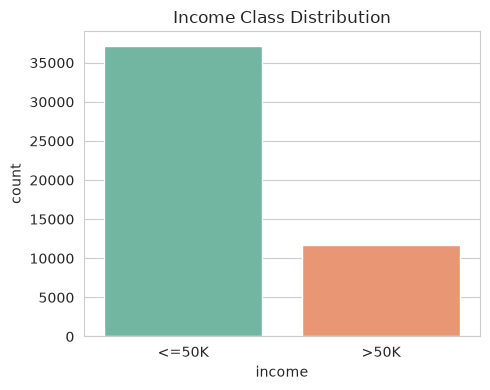

In [6]:
print(adult["income"].value_counts())
print(adult["income"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=adult, x="income", palette="Set2")
plt.title("Income Class Distribution")
plt.tight_layout()
plt.show()

## 1.4 Numeric Feature Distributions

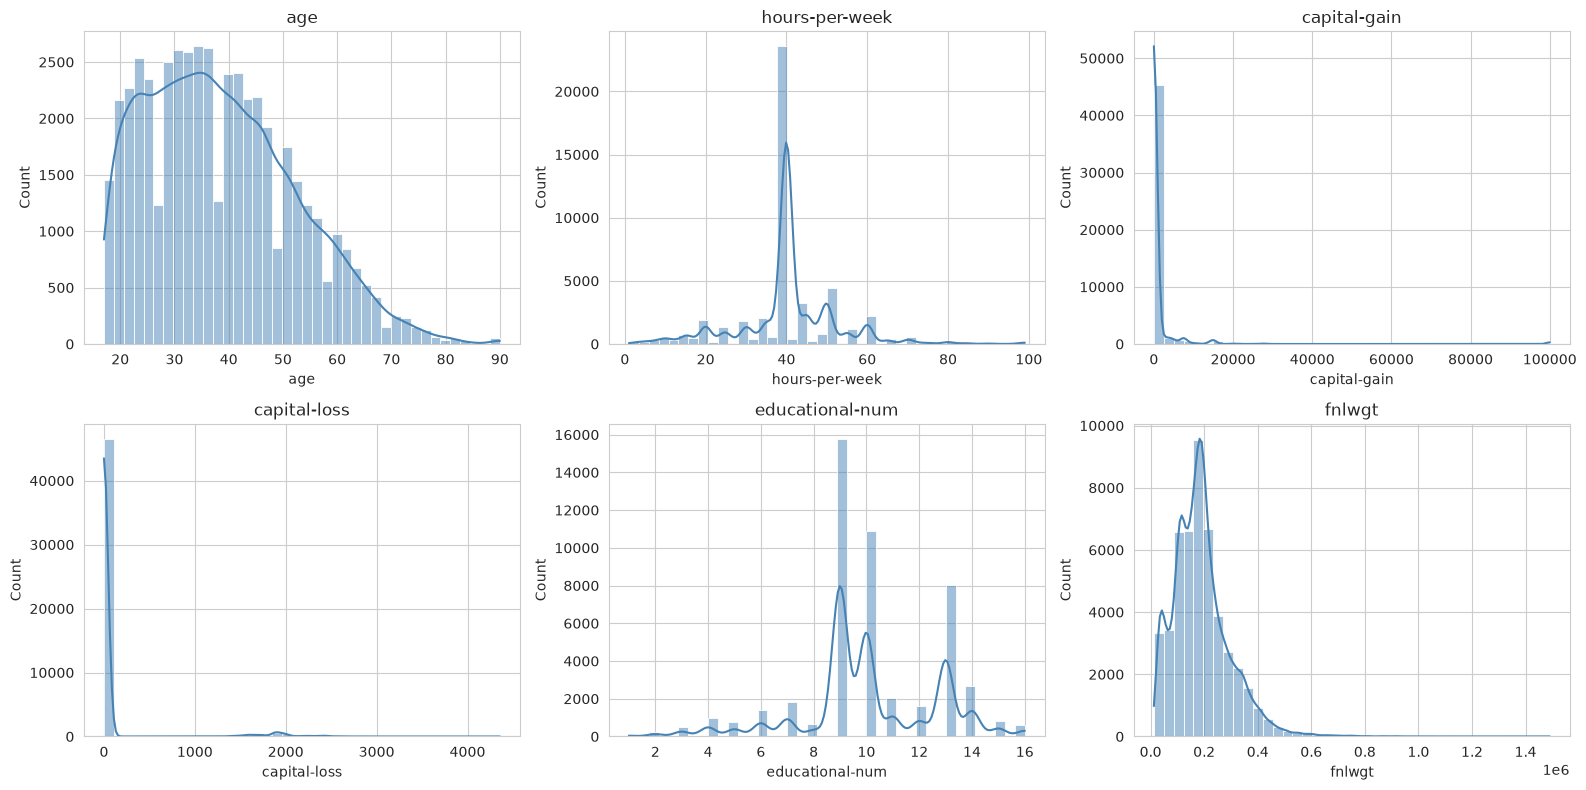

In [7]:
num_cols = ["age", "hours-per-week", "capital-gain", "capital-loss", "educational-num", "fnlwgt"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(adult[col], bins=40, ax=ax, kde=True, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 1.5 Categorical Feature Distributions

/tmp/ipykernel_389/4021965469.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=adult, y=col, order=order, ax=ax, palette="viridis")
/tmp/ipykernel_389/4021965469.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=adult, y=col, order=order, ax=ax, palette="viridis")
/tmp/ipykernel_389/4021965469.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=adult, y=col, order=order, ax=ax, palette="viridis")
/tmp/ipykernel_389/4021965469.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

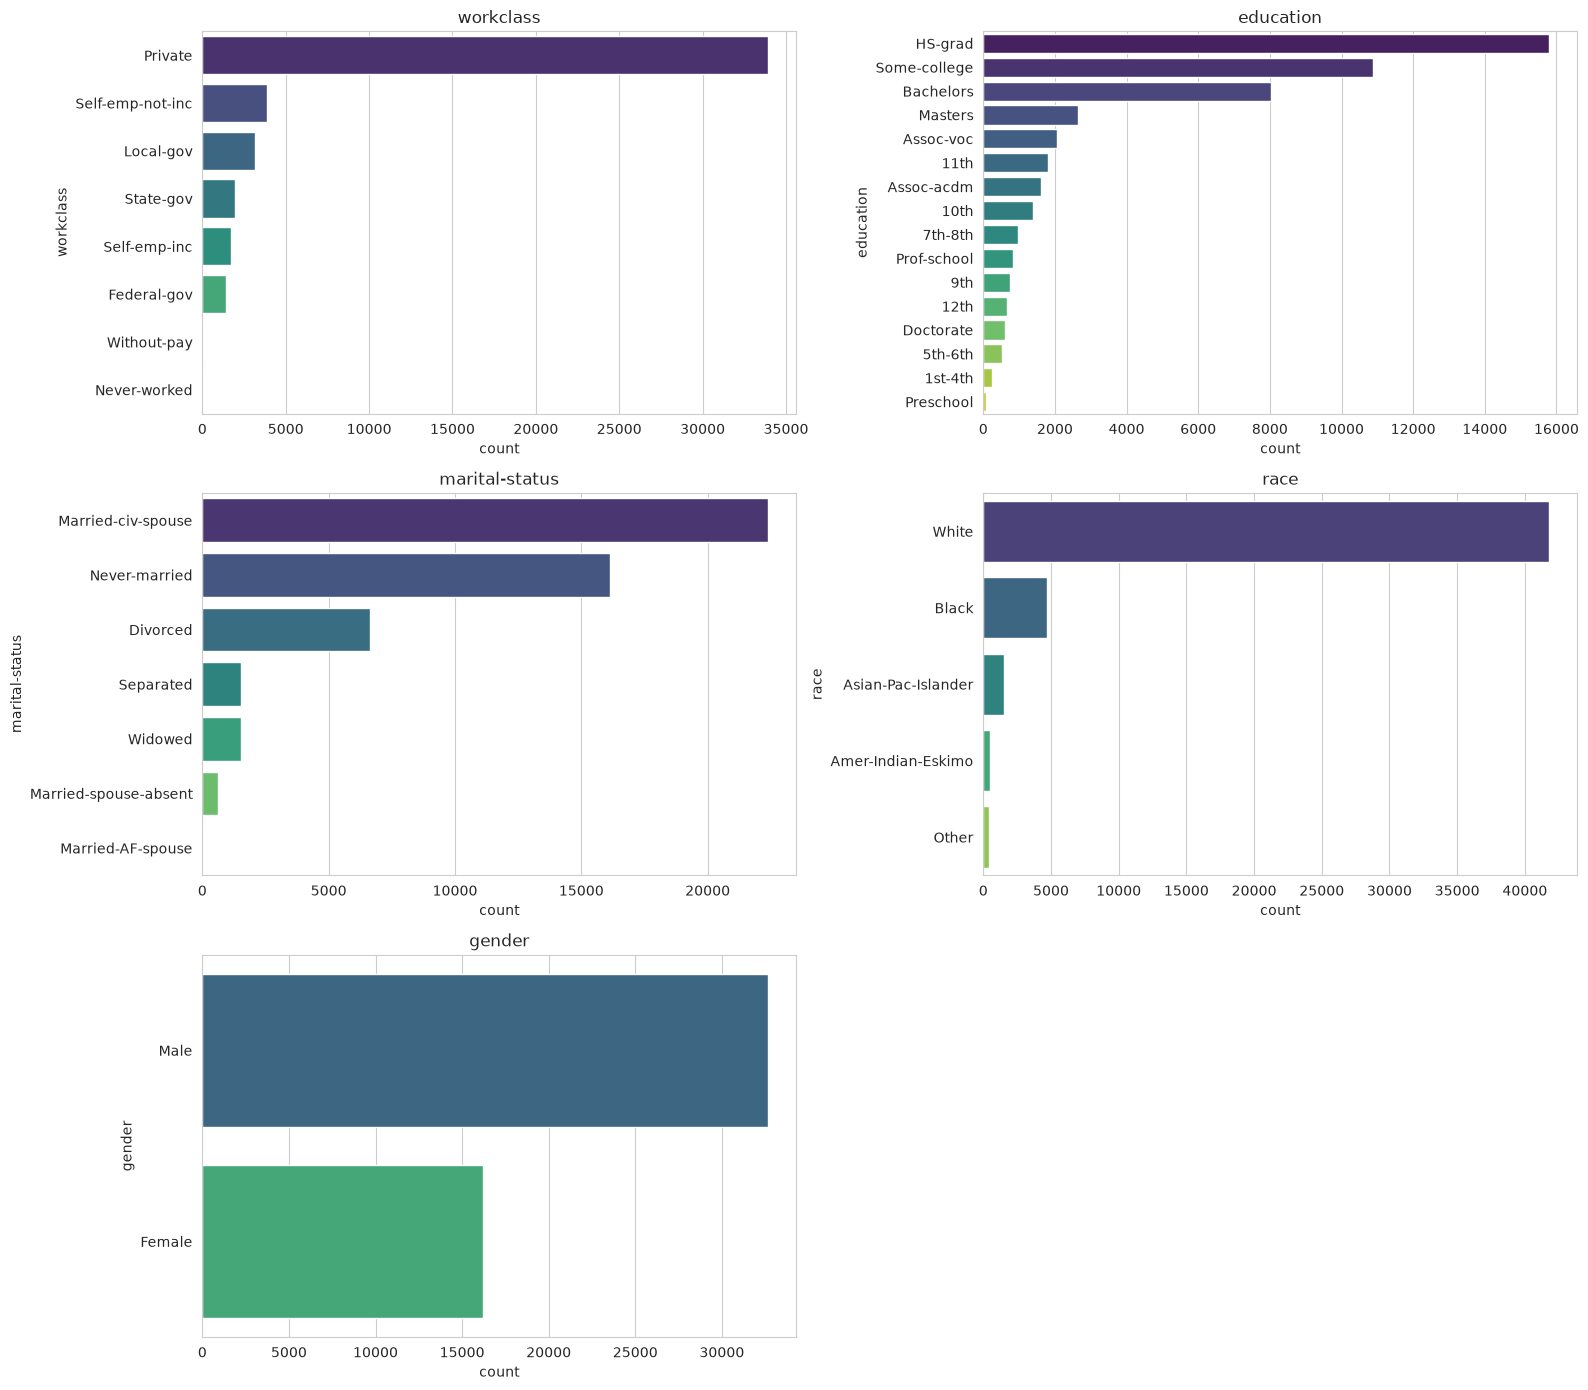

In [8]:
cat_cols = ["workclass", "education", "marital-status", "race", "gender"]
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = adult[col].value_counts().index
    sns.countplot(data=adult, y=col, order=order, ax=ax, palette="viridis")
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

## 1.6 Relationships with Income

/tmp/ipykernel_389/108815732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=adult, x="income", y="age", ax=axes[0], palette="Set3")
/tmp/ipykernel_389/108815732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=adult, x="income", y="hours-per-week", ax=axes[1], palette="Set3")


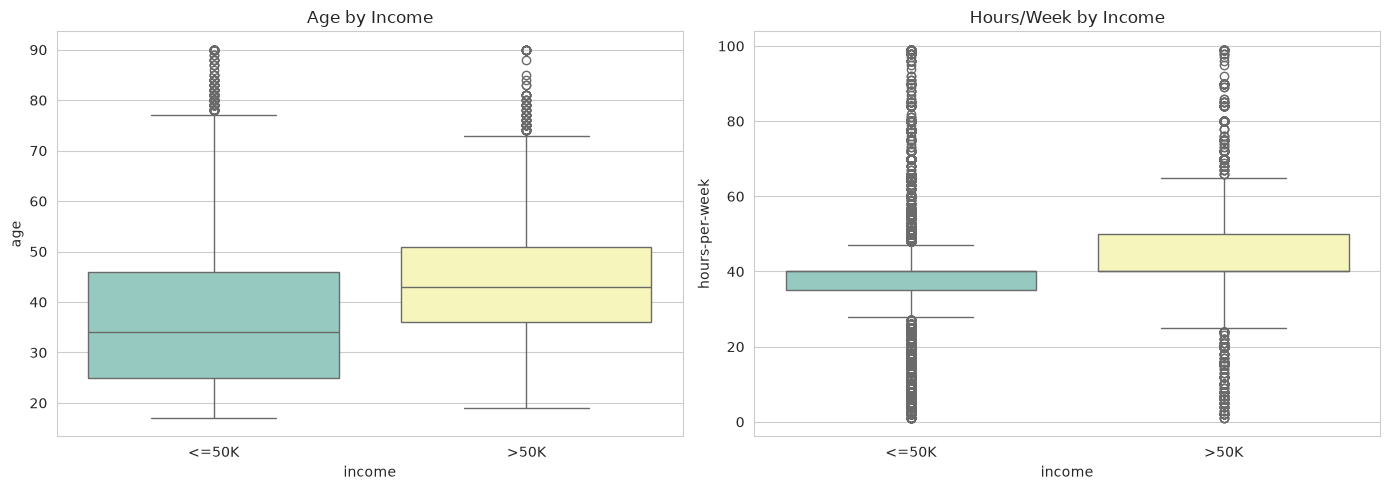

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=adult, x="income", y="age", ax=axes[0], palette="Set3")
axes[0].set_title("Age by Income")
sns.boxplot(data=adult, x="income", y="hours-per-week", ax=axes[1], palette="Set3")
axes[1].set_title("Hours/Week by Income")
plt.tight_layout()
plt.show()

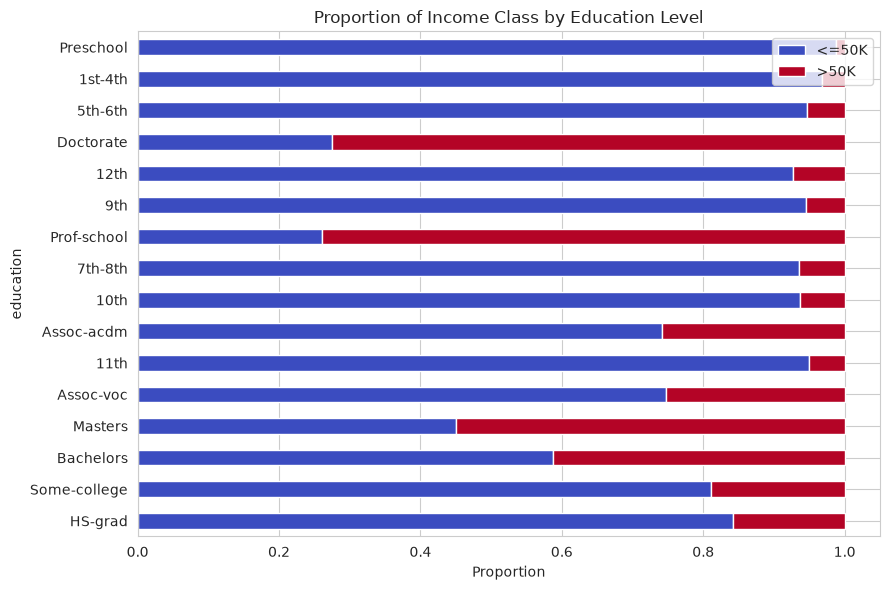

In [10]:
edu_income = pd.crosstab(adult["education"], adult["income"], normalize="index")
edu_income = edu_income.reindex(adult["education"].value_counts().index)
edu_income.plot(kind="barh", stacked=True, colormap="coolwarm", figsize=(9,6))
plt.title("Proportion of Income Class by Education Level")
plt.xlabel("Proportion")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 1.7 Correlation Between Numeric Features

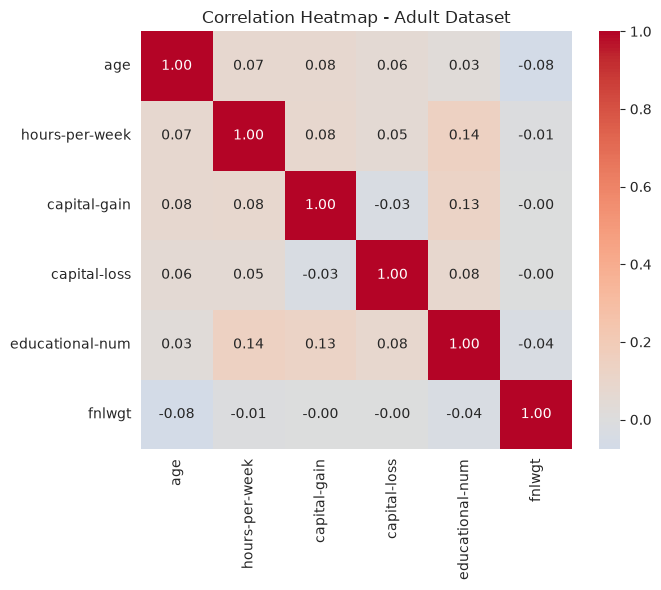

In [11]:
plt.figure(figsize=(7, 6))
corr = adult[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Adult Dataset")
plt.tight_layout()
plt.show()

---
# 2. Hotel Booking Demand Dataset (`hotel_booking.csv`)

## 2.1 Load & Basic Structure

In [12]:
hotel = pd.read_csv("hotel_booking.csv")
print("Shape:", hotel.shape)
hotel.head()

Shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [13]:
hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## 2.2 Missing Values

company     112593
agent        16340
country        488
children         4
dtype: int64


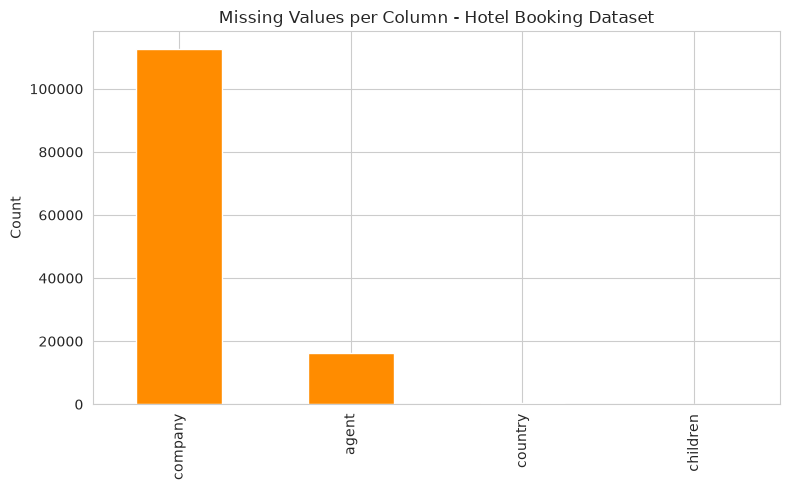

In [14]:
missing_h = hotel.isnull().sum()
missing_h = missing_h[missing_h > 0].sort_values(ascending=False)
print(missing_h)

plt.figure(figsize=(8, 5))
missing_h.plot(kind="bar", color="darkorange")
plt.title("Missing Values per Column - Hotel Booking Dataset")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Target-ish Variable: `is_canceled`

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


/tmp/ipykernel_389/1137333947.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel, x="is_canceled", palette="Set2")


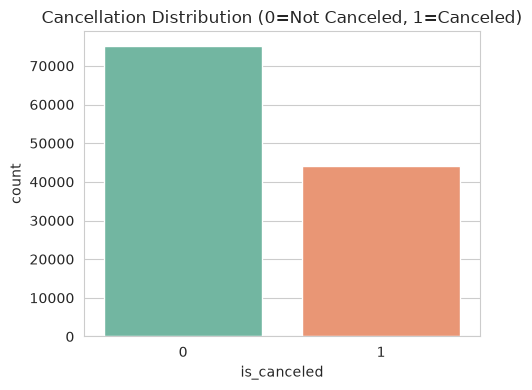

In [15]:
print(hotel["is_canceled"].value_counts())
print(hotel["is_canceled"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=hotel, x="is_canceled", palette="Set2")
plt.title("Cancellation Distribution (0=Not Canceled, 1=Canceled)")
plt.tight_layout()
plt.show()

## 2.4 Hotel Type & Cancellation Rate

/tmp/ipykernel_389/1501897105.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel, x="hotel", palette="pastel", ax=axes[0])


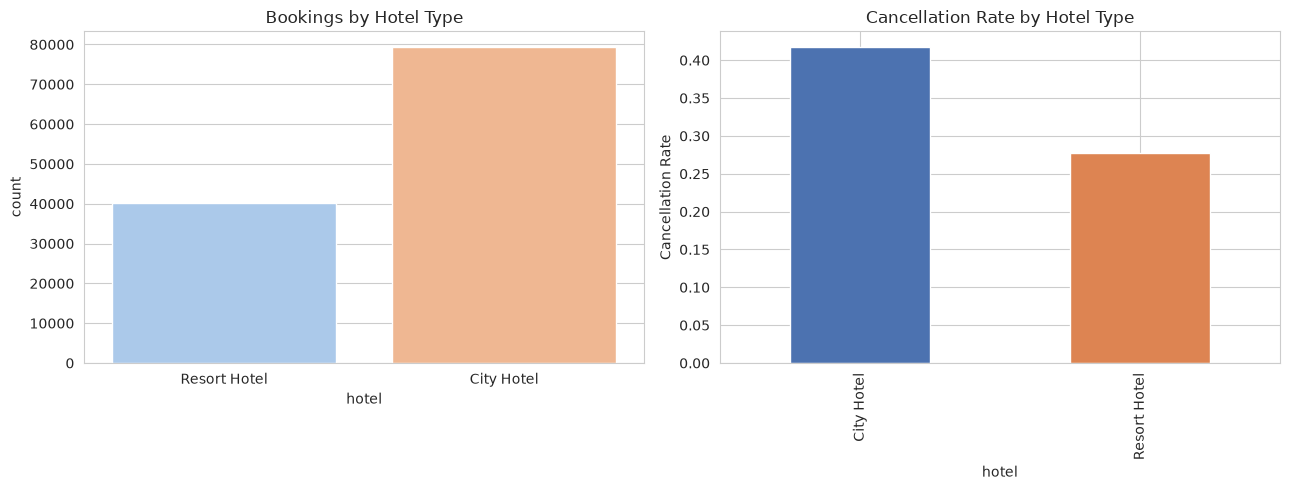

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=hotel, x="hotel", palette="pastel", ax=axes[0])
axes[0].set_title("Bookings by Hotel Type")

cancel_by_hotel = hotel.groupby("hotel")["is_canceled"].mean()
cancel_by_hotel.plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=axes[1])
axes[1].set_title("Cancellation Rate by Hotel Type")
axes[1].set_ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

## 2.5 Lead Time & ADR (Average Daily Rate) Distributions

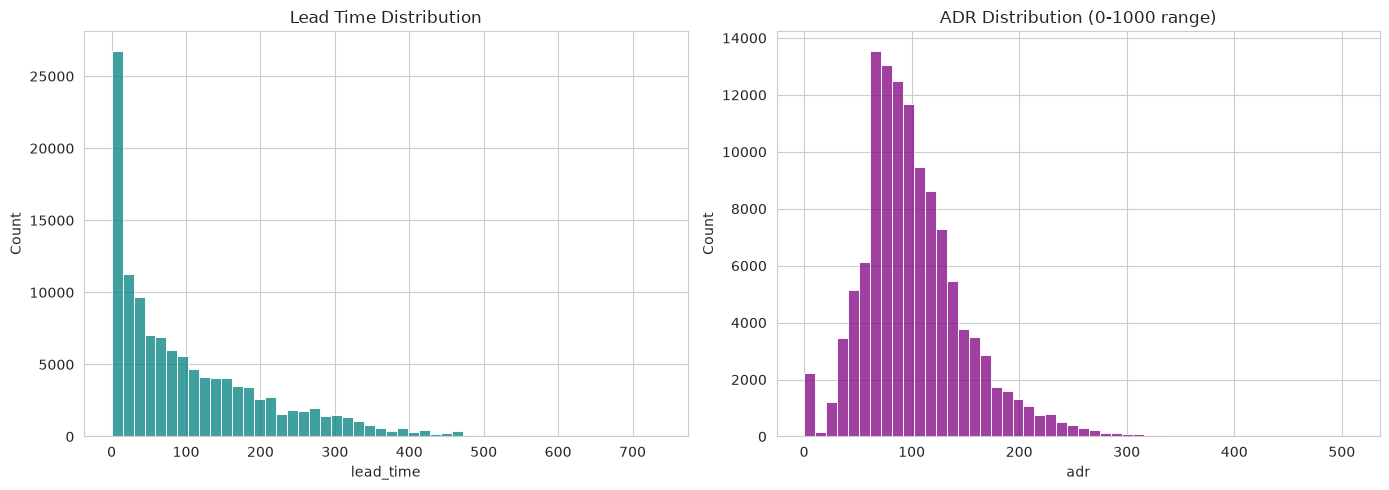

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(hotel["lead_time"], bins=50, ax=axes[0], color="teal")
axes[0].set_title("Lead Time Distribution")

adr_clean = hotel[hotel["adr"].between(0, 1000)]  # remove extreme outliers for viz
sns.histplot(adr_clean["adr"], bins=50, ax=axes[1], color="purple")
axes[1].set_title("ADR Distribution (0-1000 range)")
plt.tight_layout()
plt.show()

## 2.6 Monthly Booking Trends

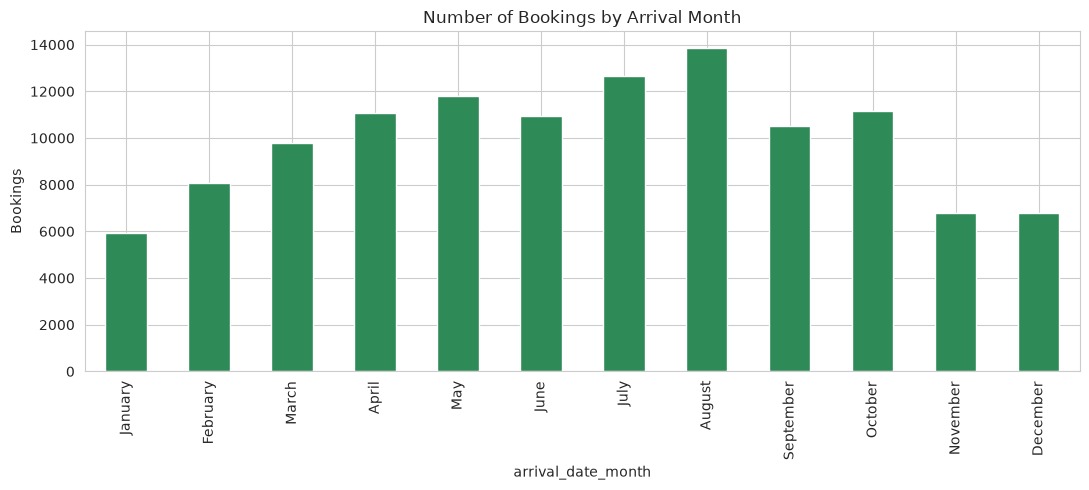

In [18]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
monthly = hotel["arrival_date_month"].value_counts().reindex(month_order)

plt.figure(figsize=(11, 5))
monthly.plot(kind="bar", color="seagreen")
plt.title("Number of Bookings by Arrival Month")
plt.ylabel("Bookings")
plt.tight_layout()
plt.show()

## 2.7 Customer Type & Deposit Type

/tmp/ipykernel_389/1454565863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel, x="customer_type", order=hotel["customer_type"].value_counts().index, ax=axes[0], palette="crest")
/tmp/ipykernel_389/1454565863.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel, x="deposit_type", order=hotel["deposit_type"].value_counts().index, ax=axes[1], palette="flare")


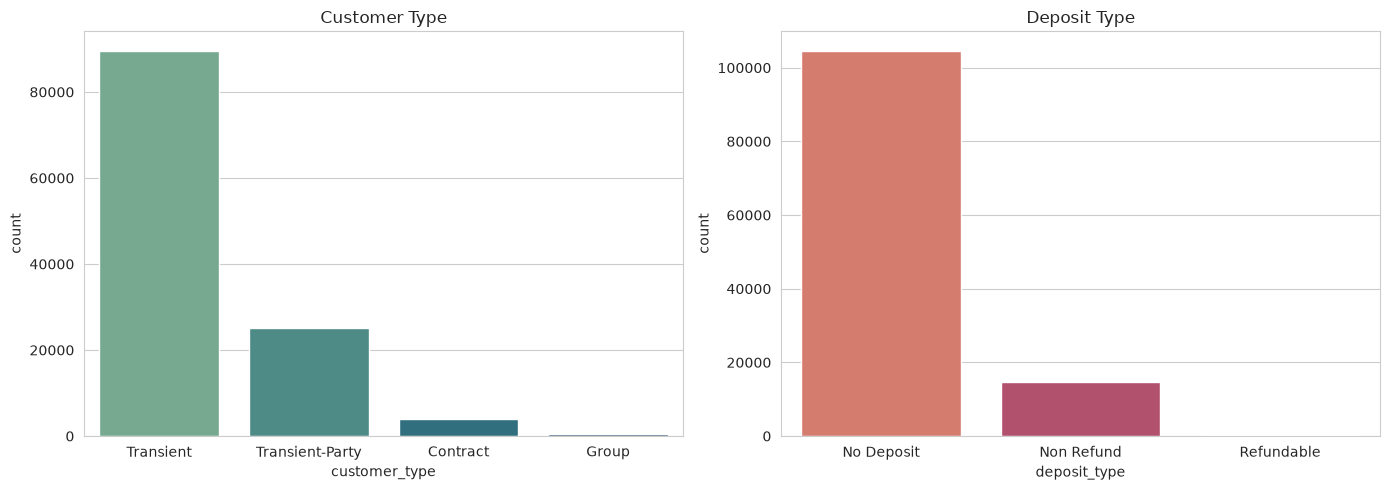

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=hotel, x="customer_type", order=hotel["customer_type"].value_counts().index, ax=axes[0], palette="crest")
axes[0].set_title("Customer Type")
sns.countplot(data=hotel, x="deposit_type", order=hotel["deposit_type"].value_counts().index, ax=axes[1], palette="flare")
axes[1].set_title("Deposit Type")
plt.tight_layout()
plt.show()

## 2.8 Correlation Between Numeric Features

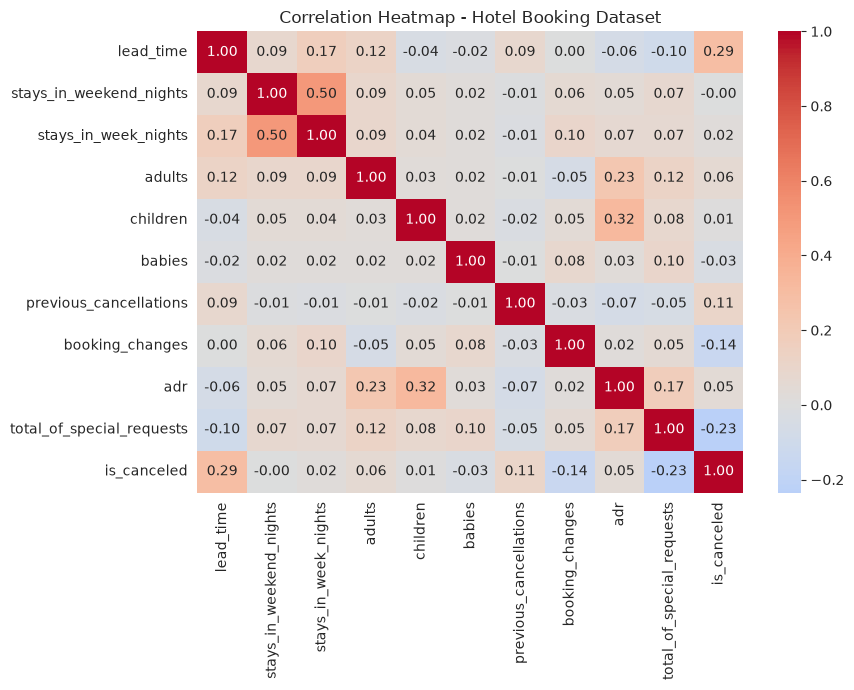

In [20]:
num_cols_h = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
              "adults", "children", "babies", "previous_cancellations",
              "booking_changes", "adr", "total_of_special_requests", "is_canceled"]
plt.figure(figsize=(9, 7))
corr_h = hotel[num_cols_h].corr()
sns.heatmap(corr_h, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Hotel Booking Dataset")
plt.tight_layout()
plt.show()

---
# 3. Loan Prediction Dataset (`loan-train.csv`)

## 3.1 Load & Basic Structure

In [21]:
loan = pd.read_csv("loan-train.csv")
print("Shape:", loan.shape)
loan.head()

Shape: (1614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [22]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1601 non-null   str    
 2   Married            1611 non-null   str    
 3   Dependents         1599 non-null   str    
 4   Education          1614 non-null   str    
 5   Self_Employed      1582 non-null   str    
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 164.1 KB


In [23]:
loan.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,1614,1538,LP006706,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1601,2,Male,980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,1611,2,Yes,925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,1599,4,0,619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1614,2,Graduate,952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,1582,2,No,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,1614.0,NaN,NaN,NaN,8746.304833,6249.885122,150.0,3675.25,7045.0,13251.0,81000.0
CoapplicantIncome,1614.0,NaN,NaN,NaN,3658.722999,3291.745935,0.0,986.25,2941.5,5893.0,41667.0
LoanAmount,1592.0,NaN,NaN,NaN,218.846734,133.623293,9.0,112.0,180.0,324.0,700.0
Loan_Amount_Term,1600.0,NaN,NaN,NaN,290.475,81.899735,12.0,240.0,360.0,360.0,480.0


## 3.2 Missing Values

Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64


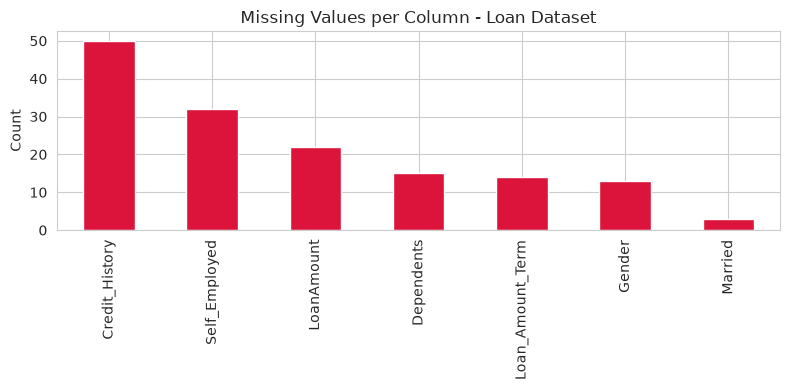

In [24]:
missing_l = loan.isnull().sum()
missing_l = missing_l[missing_l > 0].sort_values(ascending=False)
print(missing_l)

plt.figure(figsize=(8, 4))
missing_l.plot(kind="bar", color="crimson")
plt.title("Missing Values per Column - Loan Dataset")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 3.3 Target Variable: `Loan_Status`

Loan_Status
Y    915
N    699
Name: count, dtype: int64
Loan_Status
Y    0.567
N    0.433
Name: proportion, dtype: float64


/tmp/ipykernel_389/3502436867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=loan, x="Loan_Status", palette="Set2")


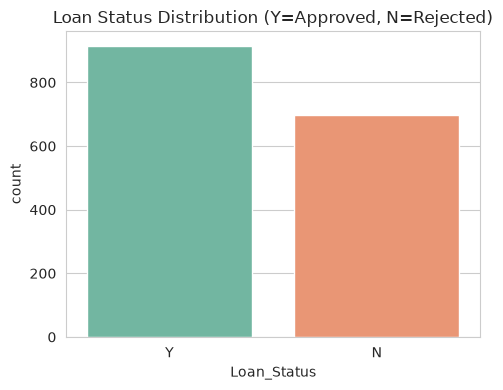

In [25]:
print(loan["Loan_Status"].value_counts())
print(loan["Loan_Status"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=loan, x="Loan_Status", palette="Set2")
plt.title("Loan Status Distribution (Y=Approved, N=Rejected)")
plt.tight_layout()
plt.show()

## 3.4 Categorical Feature Distributions

/tmp/ipykernel_389/3314136921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=loan, x=col, order=loan[col].value_counts().index, ax=ax, palette="mako")
/tmp/ipykernel_389/3314136921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=loan, x=col, order=loan[col].value_counts().index, ax=ax, palette="mako")
/tmp/ipykernel_389/3314136921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=loan, x=col, order=loan[col].value_counts().index, ax=ax, palette="mako")
/tmp/ipykernel_389/3314136921.py:4: FutureWarning: 

Passi

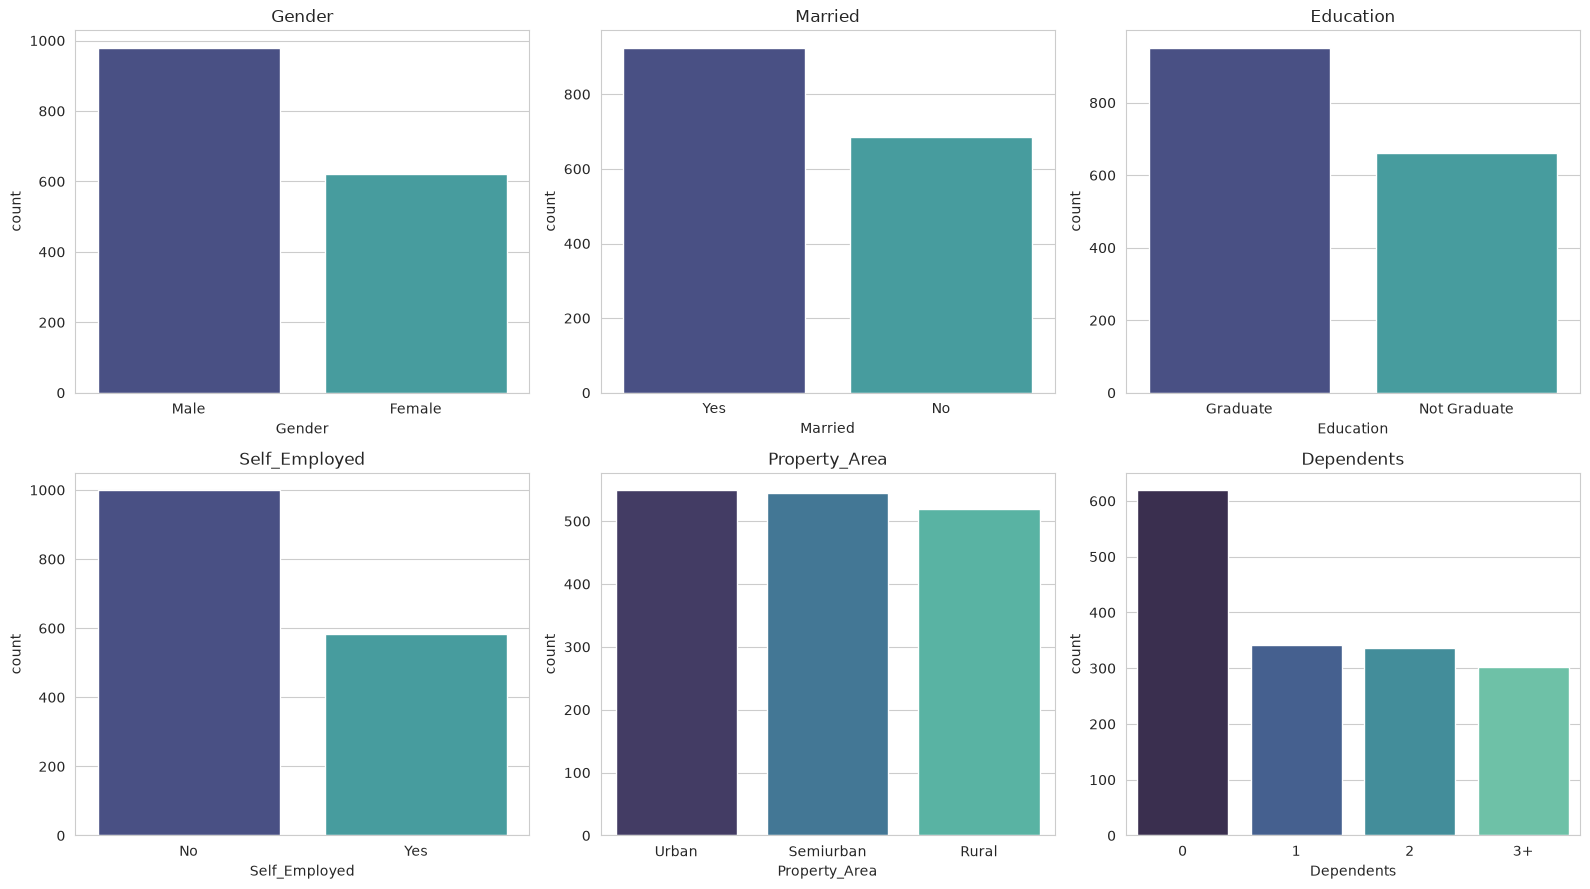

In [26]:
cat_cols_l = ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Dependents"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols_l):
    sns.countplot(data=loan, x=col, order=loan[col].value_counts().index, ax=ax, palette="mako")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3.5 Numeric Feature Distributions

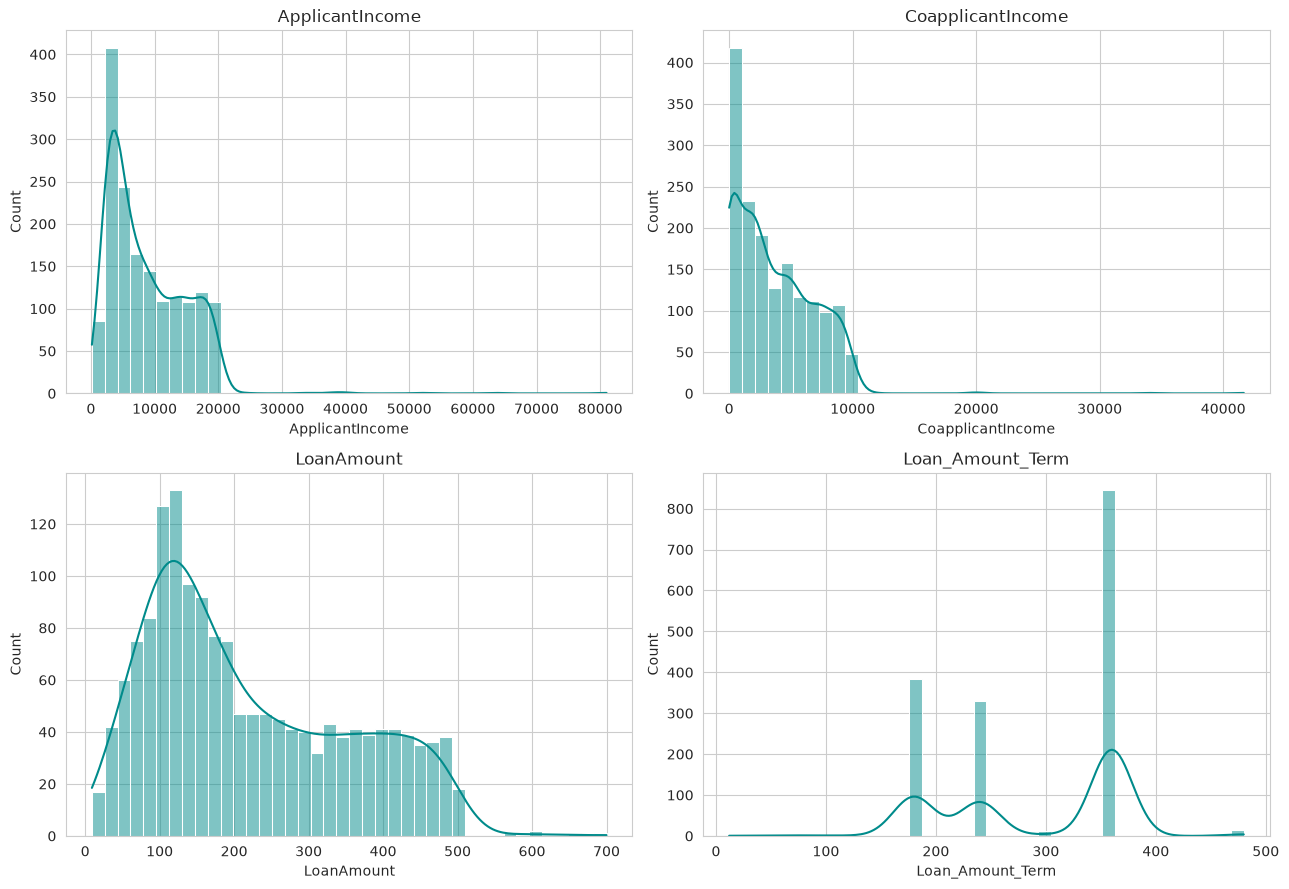

In [27]:
num_cols_l = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), num_cols_l):
    sns.histplot(loan[col].dropna(), bins=40, kde=True, ax=ax, color="darkcyan")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3.6 Relationships with Loan Status

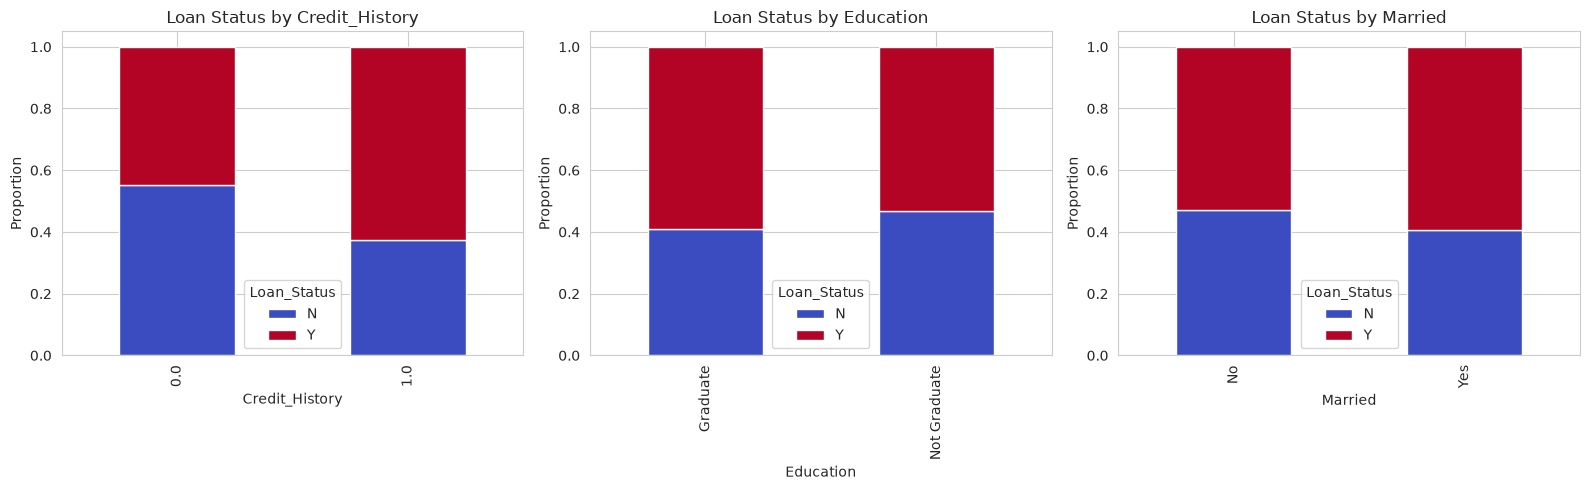

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Credit_History", "Education", "Married"]):
    ct = pd.crosstab(loan[col], loan["Loan_Status"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm")
    ax.set_title(f"Loan Status by {col}")
    ax.set_ylabel("Proportion")
plt.tight_layout()
plt.show()

/tmp/ipykernel_389/6791920.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loan, x="Loan_Status", y="ApplicantIncome", palette="Set3", showfliers=False)


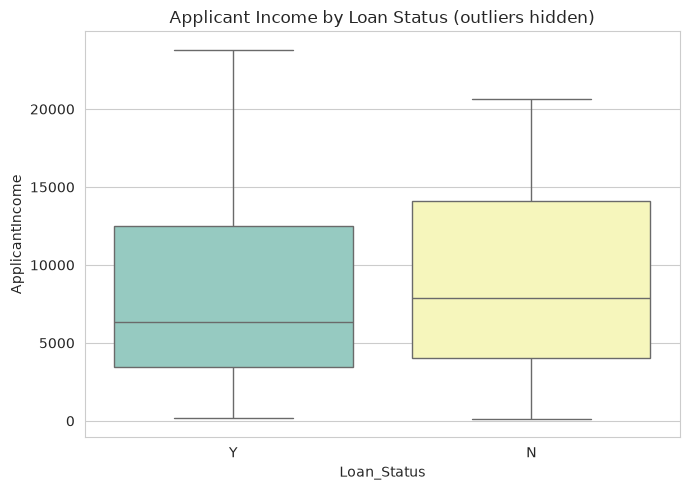

In [29]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=loan, x="Loan_Status", y="ApplicantIncome", palette="Set3", showfliers=False)
plt.title("Applicant Income by Loan Status (outliers hidden)")
plt.tight_layout()
plt.show()

## 3.7 Correlation Between Numeric Features

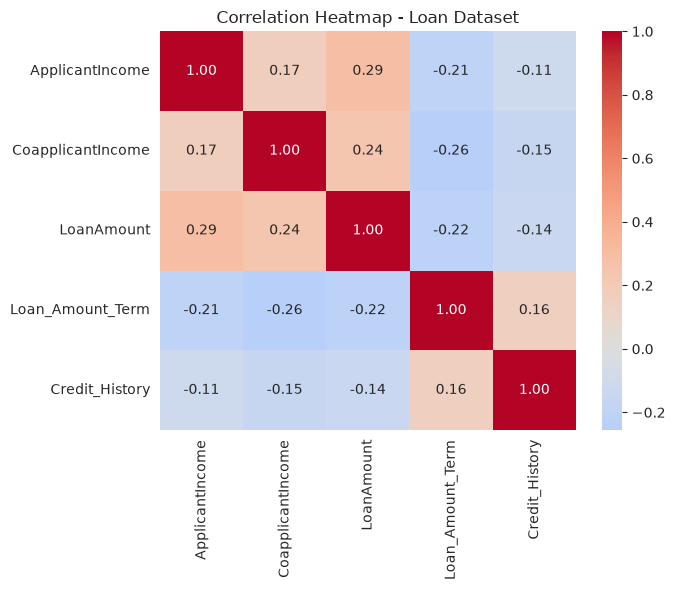

In [30]:
num_corr_l = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
plt.figure(figsize=(7, 6))
sns.heatmap(loan[num_corr_l].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Loan Dataset")
plt.tight_layout()
plt.show()

---
# 4. Data Cleaning & Export

The EDA above surfaced specific data quality issues in each dataset. This section makes an explicit,
documented decision for each issue, applies it, and exports a cleaned CSV so the raw EDA above stays
untouched as the "diagnosis" step.

## 4.1 Cleaning `adult.csv`

**Issues found & decisions:**
- `?` placeholders → already mapped to `NaN` above; affects `workclass`, `occupation`, `native-country`.
- These are all categorical columns with a dominant mode — impute missing values with the column mode
  rather than dropping ~7% of rows.
- Check and drop exact duplicate rows.
- Strip stray whitespace from string columns (a known quirk of this dataset's raw text).

In [31]:
adult_clean = adult.copy()

# Strip whitespace from all object/string columns
obj_cols = adult_clean.select_dtypes(include="object").columns
for c in obj_cols:
    adult_clean[c] = adult_clean[c].str.strip()

before_missing = adult_clean.isnull().sum()
before_missing = before_missing[before_missing > 0]
print("Missing before imputation:")
print(before_missing)

for c in ["workclass", "occupation", "native-country"]:
    mode_val = adult_clean[c].mode(dropna=True)[0]
    adult_clean[c] = adult_clean[c].fillna(mode_val)

dupes = adult_clean.duplicated().sum()
print(f"\nExact duplicate rows: {dupes}")
adult_clean = adult_clean.drop_duplicates()

print(f"\nMissing after cleaning: {adult_clean.isnull().sum().sum()}")
print(f"Shape before: {adult.shape}  ->  after: {adult_clean.shape}")

adult_clean.to_csv("adult_cleaned.csv", index=False)
print("Saved adult_cleaned.csv")

/tmp/ipykernel_389/129313929.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = adult_clean.select_dtypes(include="object").columns


Missing before imputation:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Exact duplicate rows: 53

Missing after cleaning: 0
Shape before: (48842, 15)  ->  after: (48789, 15)
Saved adult_cleaned.csv


## 4.2 Cleaning `hotel_booking.csv`

**Issues found & decisions:**
- `name`, `email`, `phone-number`, `credit_card` — these are personally identifiable information (PII)
  that add no analytical value and shouldn't be persisted downstream. **Drop these columns.**
- `children` — a small number of missing values; a missing headcount most plausibly means 0. **Fill with 0.**
- `country` — fill missing with `"Unknown"` rather than dropping rows.
- `agent`, `company` — missing here means "no agent" / "no company" (not a data collection failure),
  so these are meaningful, not random. **Fill with 0** (no valid agent/company ID is 0).
- `reservation_status_date` — parse to an actual `datetime` type.
- Known data-quality issue in this public dataset: some rows have `adults + children + babies == 0`
  (a booking with zero guests), and a small number of extreme `adr` outliers (including one negative
  value and one value near 5400). **Drop zero-guest rows and clip/remove implausible `adr` values.**

In [32]:
hotel_clean = hotel.copy()

pii_cols = ["name", "email", "phone-number", "credit_card"]
hotel_clean = hotel_clean.drop(columns=pii_cols)

before_missing_h = hotel_clean.isnull().sum()
before_missing_h = before_missing_h[before_missing_h > 0]
print("Missing before cleaning:")
print(before_missing_h)

hotel_clean["children"] = hotel_clean["children"].fillna(0)
hotel_clean["country"] = hotel_clean["country"].fillna("Unknown")
hotel_clean["agent"] = hotel_clean["agent"].fillna(0)
hotel_clean["company"] = hotel_clean["company"].fillna(0)

hotel_clean["reservation_status_date"] = pd.to_datetime(hotel_clean["reservation_status_date"])

zero_guest_mask = (hotel_clean["adults"] + hotel_clean["children"] + hotel_clean["babies"]) == 0
print(f"\nRows with zero total guests: {zero_guest_mask.sum()}")
hotel_clean = hotel_clean[~zero_guest_mask]

adr_bad_mask = (hotel_clean["adr"] < 0) | (hotel_clean["adr"] > 1000)
print(f"Rows with implausible adr (<0 or >1000): {adr_bad_mask.sum()}")
hotel_clean = hotel_clean[~adr_bad_mask]

print(f"\nMissing after cleaning: {hotel_clean.isnull().sum().sum()}")
print(f"Shape before: {hotel.shape}  ->  after: {hotel_clean.shape}")

hotel_clean.to_csv("hotel_booking_cleaned.csv", index=False)
print("Saved hotel_booking_cleaned.csv")

Missing before cleaning:
children         4
country        488
agent        16340
company     112593
dtype: int64

Rows with zero total guests: 180
Rows with implausible adr (<0 or >1000): 2

Missing after cleaning: 0
Shape before: (119390, 36)  ->  after: (119208, 32)
Saved hotel_booking_cleaned.csv


## 4.3 Cleaning `loan-train.csv`

**Issues found & decisions:**
- `Credit_History` — missing values are meaningful (bureau has no record) but for modeling purposes,
  impute with the **mode** (1.0, the dominant class) rather than dropping ~8% of rows.
- `LoanAmount` — impute with the **median** (robust to the right-skew seen in the EDA histogram).
- `Loan_Amount_Term` — impute with the **mode** (360 months dominates heavily).
- `Gender`, `Married`, `Dependents`, `Self_Employed` — low-missingness categorical columns,
  impute with **mode**.
- Check and drop exact duplicate rows (none expected given `Loan_ID` is unique, but verify).

In [33]:
loan_clean = loan.copy()

before_missing_l = loan_clean.isnull().sum()
before_missing_l = before_missing_l[before_missing_l > 0]
print("Missing before cleaning:")
print(before_missing_l)

loan_clean["Credit_History"] = loan_clean["Credit_History"].fillna(loan_clean["Credit_History"].mode()[0])
loan_clean["LoanAmount"] = loan_clean["LoanAmount"].fillna(loan_clean["LoanAmount"].median())
loan_clean["Loan_Amount_Term"] = loan_clean["Loan_Amount_Term"].fillna(loan_clean["Loan_Amount_Term"].mode()[0])

for c in ["Gender", "Married", "Dependents", "Self_Employed"]:
    loan_clean[c] = loan_clean[c].fillna(loan_clean[c].mode()[0])

dupes_l = loan_clean.duplicated(subset=[c for c in loan_clean.columns if c != "Loan_ID"]).sum()
print(f"\nDuplicate rows (excluding Loan_ID): {dupes_l}")

print(f"\nMissing after cleaning: {loan_clean.isnull().sum().sum()}")
print(f"Shape before: {loan.shape}  ->  after: {loan_clean.shape}")

loan_clean.to_csv("loan_train_cleaned.csv", index=False)
print("Saved loan_train_cleaned.csv")

Missing before cleaning:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

Duplicate rows (excluding Loan_ID): 0

Missing after cleaning: 0
Shape before: (1614, 13)  ->  after: (1614, 13)
Saved loan_train_cleaned.csv


## 4.4 Before / After Missingness Overview

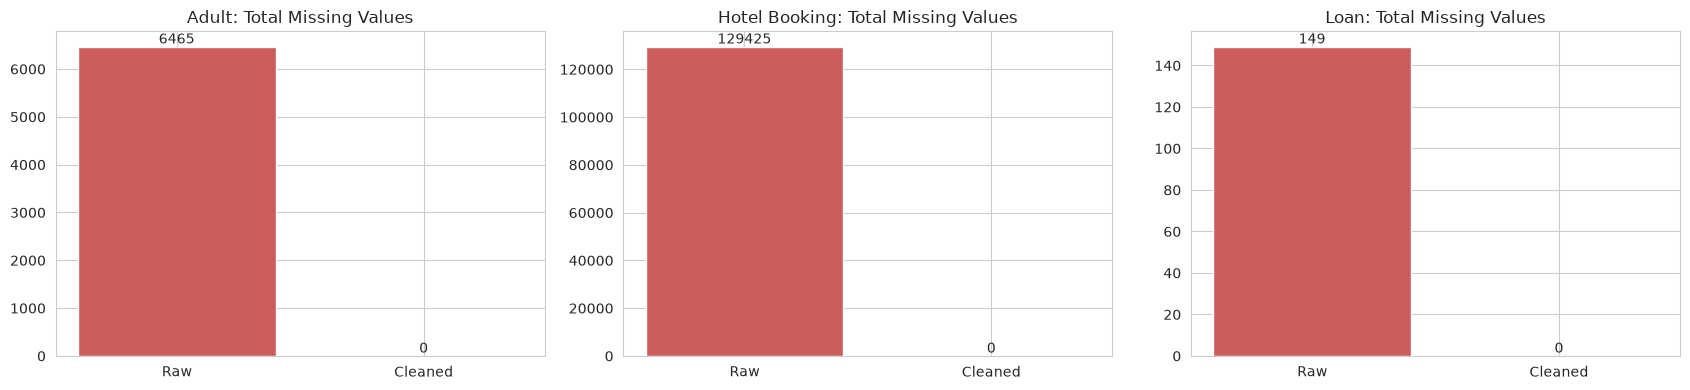

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, (name, raw_df, clean_df) in zip(
    axes,
    [("Adult", adult, adult_clean), ("Hotel Booking", hotel, hotel_clean), ("Loan", loan, loan_clean)]
):
    raw_missing = raw_df.isnull().sum().sum()
    clean_missing = clean_df.isnull().sum().sum()
    ax.bar(["Raw", "Cleaned"], [raw_missing, clean_missing], color=["indianred", "seagreen"])
    ax.set_title(f"{name}: Total Missing Values")
    for i, v in enumerate([raw_missing, clean_missing]):
        ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

---
# 5. EDA on Cleaned Data

Now that `adult_clean`, `hotel_clean`, and `loan_clean` have been produced, this section re-runs the
key EDA checks on the cleaned dataframes so we can confirm the cleaning worked as intended and see
whether any distributions shifted meaningfully (e.g. from outlier removal or imputation).

## 5.1 Adult — Cleaned

In [35]:
print("Missing values remaining:", adult_clean.isnull().sum().sum())
print("Shape:", adult_clean.shape)
adult_clean.head()

Missing values remaining: 0
Shape: (48789, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


income
<=50K    37108
>50K     11681
Name: count, dtype: int64
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


/tmp/ipykernel_389/3610771791.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=adult_clean, x="income", palette="Set2")


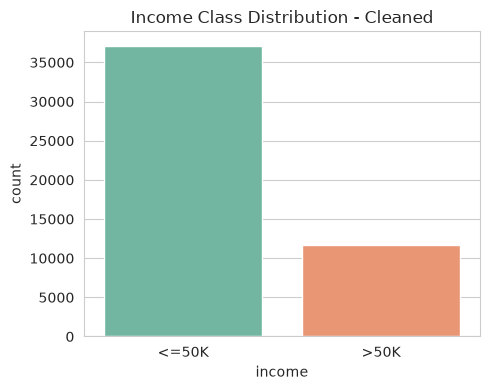

In [36]:
print(adult_clean["income"].value_counts())
print(adult_clean["income"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=adult_clean, x="income", palette="Set2")
plt.title("Income Class Distribution - Cleaned")
plt.tight_layout()
plt.show()

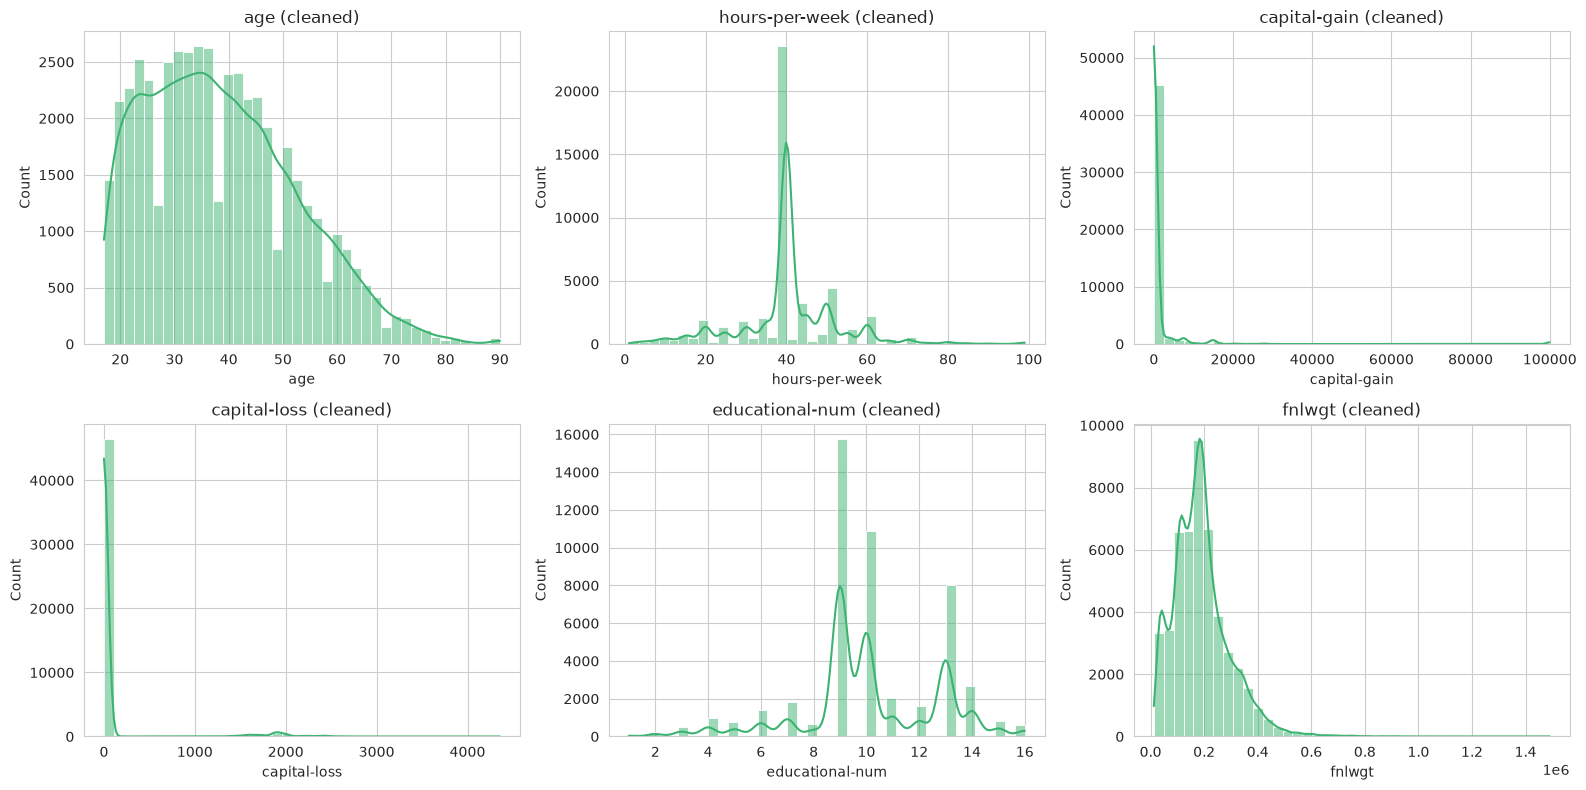

In [37]:
num_cols = ["age", "hours-per-week", "capital-gain", "capital-loss", "educational-num", "fnlwgt"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(adult_clean[col], bins=40, ax=ax, kde=True, color="mediumseagreen")
    ax.set_title(f"{col} (cleaned)")
plt.tight_layout()
plt.show()

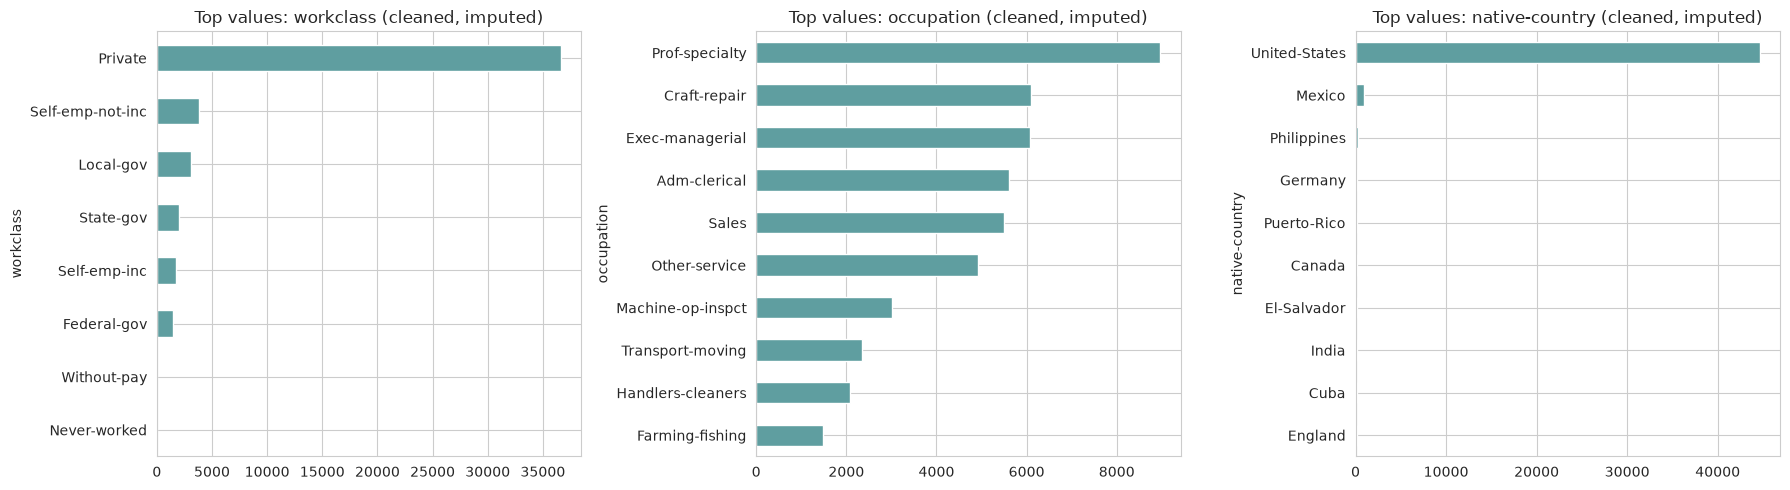

In [38]:
cat_cols = ["workclass", "occupation", "native-country"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    top_vals = adult_clean[col].value_counts().head(10)
    top_vals.plot(kind="barh", ax=ax, color="cadetblue")
    ax.set_title(f"Top values: {col} (cleaned, imputed)")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

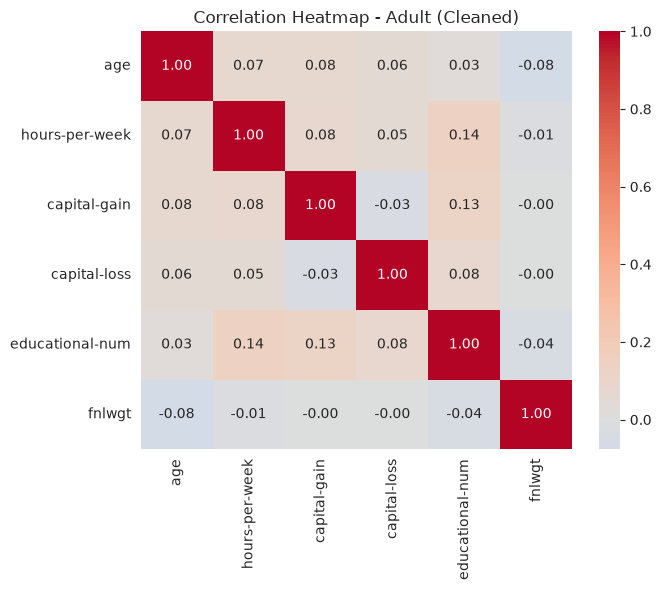

In [39]:
plt.figure(figsize=(7, 6))
corr_clean = adult_clean[num_cols].corr()
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Adult (Cleaned)")
plt.tight_layout()
plt.show()

**Observations:** Class balance is essentially unchanged (dropping 52 duplicate rows doesn't shift
proportions). The imputed `workclass`/`occupation`/`native-country` columns now show their mode value
(`Private`, `Prof-specialty`-type category, `United-States`) slightly over-represented relative to the
raw data — worth keeping in mind if these features are used in modeling, since imputation slightly
inflates the majority category rather than reflecting a true increase in prevalence.

## 5.2 Hotel Booking — Cleaned

In [40]:
print("Missing values remaining:", hotel_clean.isnull().sum().sum())
print("Shape:", hotel_clean.shape)
hotel_clean.head()

Missing values remaining: 0
Shape: (119208, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


is_canceled
0    75010
1    44198
Name: count, dtype: int64
is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64


/tmp/ipykernel_389/3183929351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel_clean, x="is_canceled", palette="Set2", ax=axes[0])


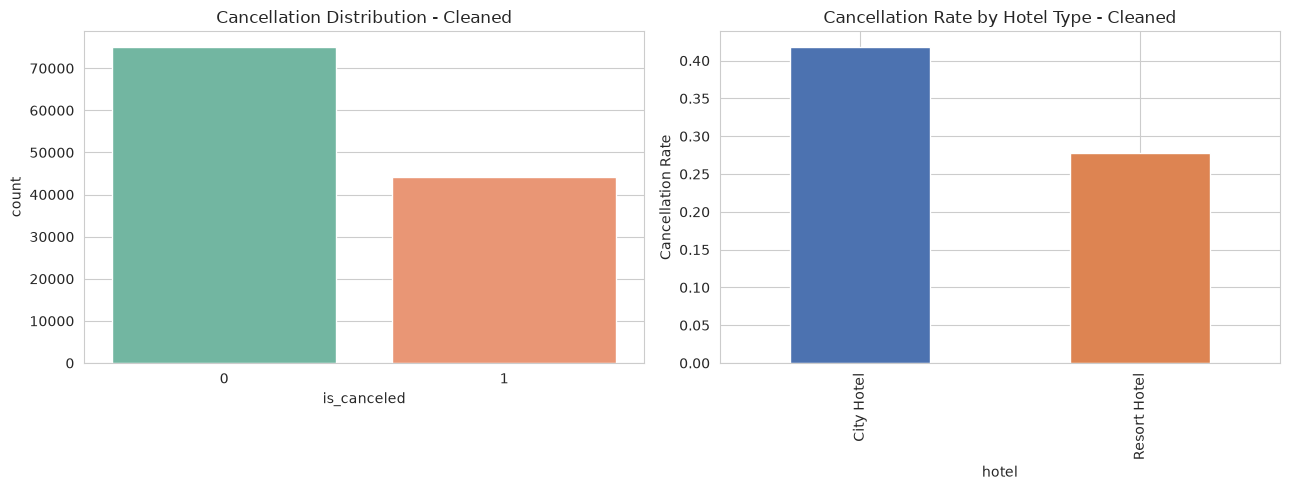

In [41]:
print(hotel_clean["is_canceled"].value_counts())
print(hotel_clean["is_canceled"].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=hotel_clean, x="is_canceled", palette="Set2", ax=axes[0])
axes[0].set_title("Cancellation Distribution - Cleaned")

cancel_by_hotel_clean = hotel_clean.groupby("hotel")["is_canceled"].mean()
cancel_by_hotel_clean.plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=axes[1])
axes[1].set_title("Cancellation Rate by Hotel Type - Cleaned")
axes[1].set_ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

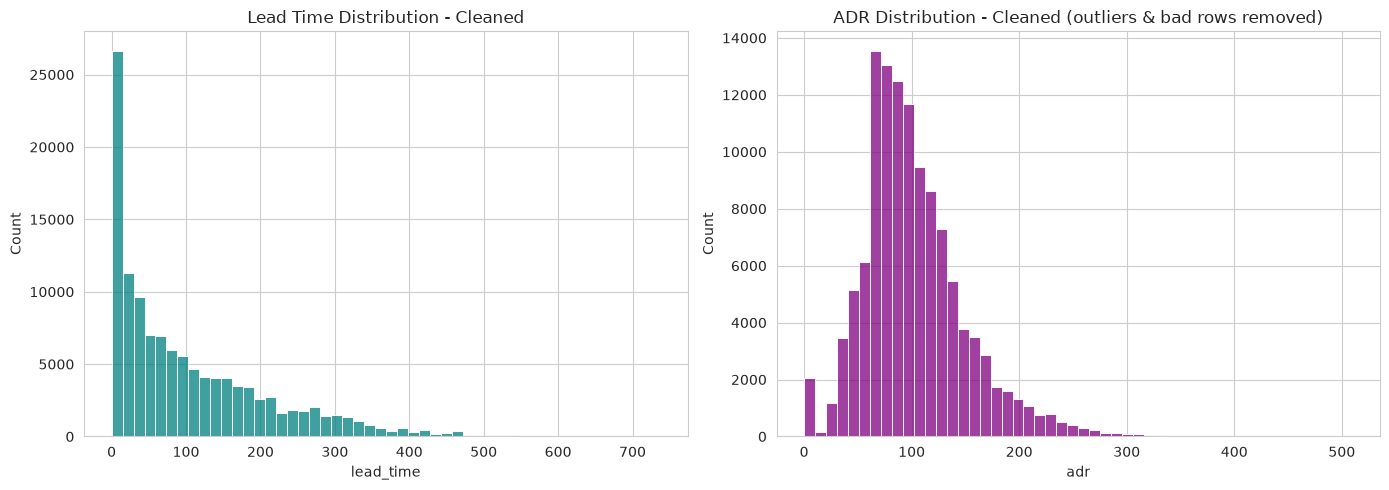

ADR range after cleaning: 0.00 to 510.00


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(hotel_clean["lead_time"], bins=50, ax=axes[0], color="teal")
axes[0].set_title("Lead Time Distribution - Cleaned")

sns.histplot(hotel_clean["adr"], bins=50, ax=axes[1], color="purple")
axes[1].set_title("ADR Distribution - Cleaned (outliers & bad rows removed)")
plt.tight_layout()
plt.show()

print("ADR range after cleaning: {:.2f} to {:.2f}".format(hotel_clean["adr"].min(), hotel_clean["adr"].max()))

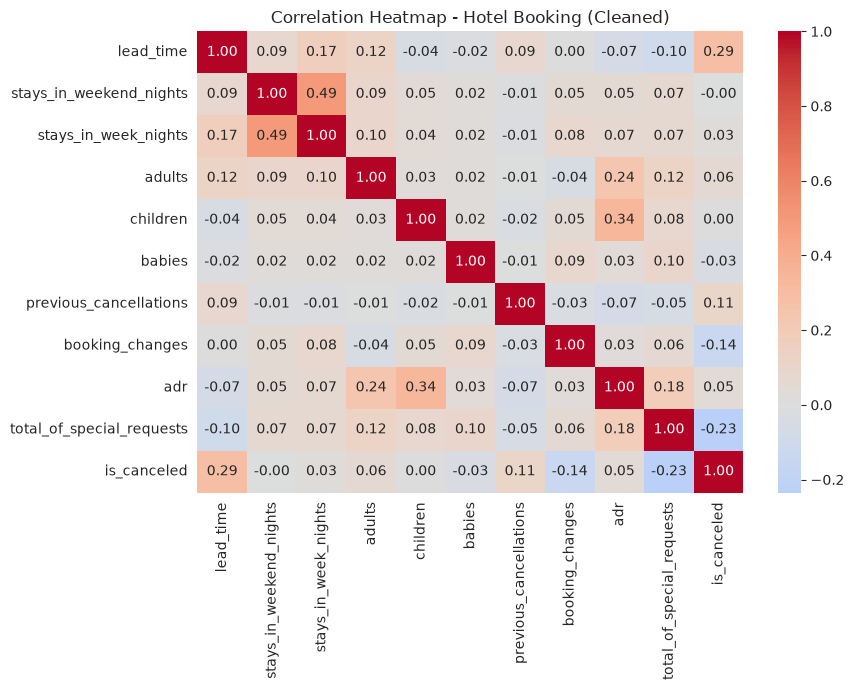

In [43]:
num_cols_h = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
              "adults", "children", "babies", "previous_cancellations",
              "booking_changes", "adr", "total_of_special_requests", "is_canceled"]
plt.figure(figsize=(9, 7))
corr_h_clean = hotel_clean[num_cols_h].corr()
sns.heatmap(corr_h_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Hotel Booking (Cleaned)")
plt.tight_layout()
plt.show()

**Observations:** The overall cancellation rate and cancellation-rate-by-hotel-type are virtually
identical to the raw data (removing zero-guest/bad-ADR rows only affected a small number of records
relative to ~119K total). The main visible difference is in the **ADR distribution**: the long right
tail and the negative value seen in the raw histogram are gone, giving a cleaner, more interpretable
shape centered in a realistic nightly-rate range.

## 5.3 Loan — Cleaned

In [44]:
print("Missing values remaining:", loan_clean.isnull().sum().sum())
print("Shape:", loan_clean.shape)
loan_clean.head()

Missing values remaining: 0
Shape: (1614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,180.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Loan_Status
Y    915
N    699
Name: count, dtype: int64
Loan_Status
Y    0.567
N    0.433
Name: proportion, dtype: float64


/tmp/ipykernel_389/1889773283.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=loan_clean, x="Loan_Status", palette="Set2")


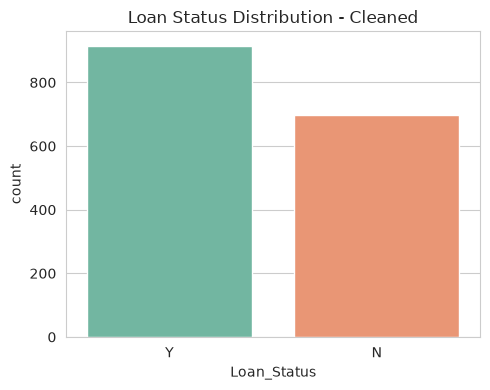

In [45]:
print(loan_clean["Loan_Status"].value_counts())
print(loan_clean["Loan_Status"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=loan_clean, x="Loan_Status", palette="Set2")
plt.title("Loan Status Distribution - Cleaned")
plt.tight_layout()
plt.show()

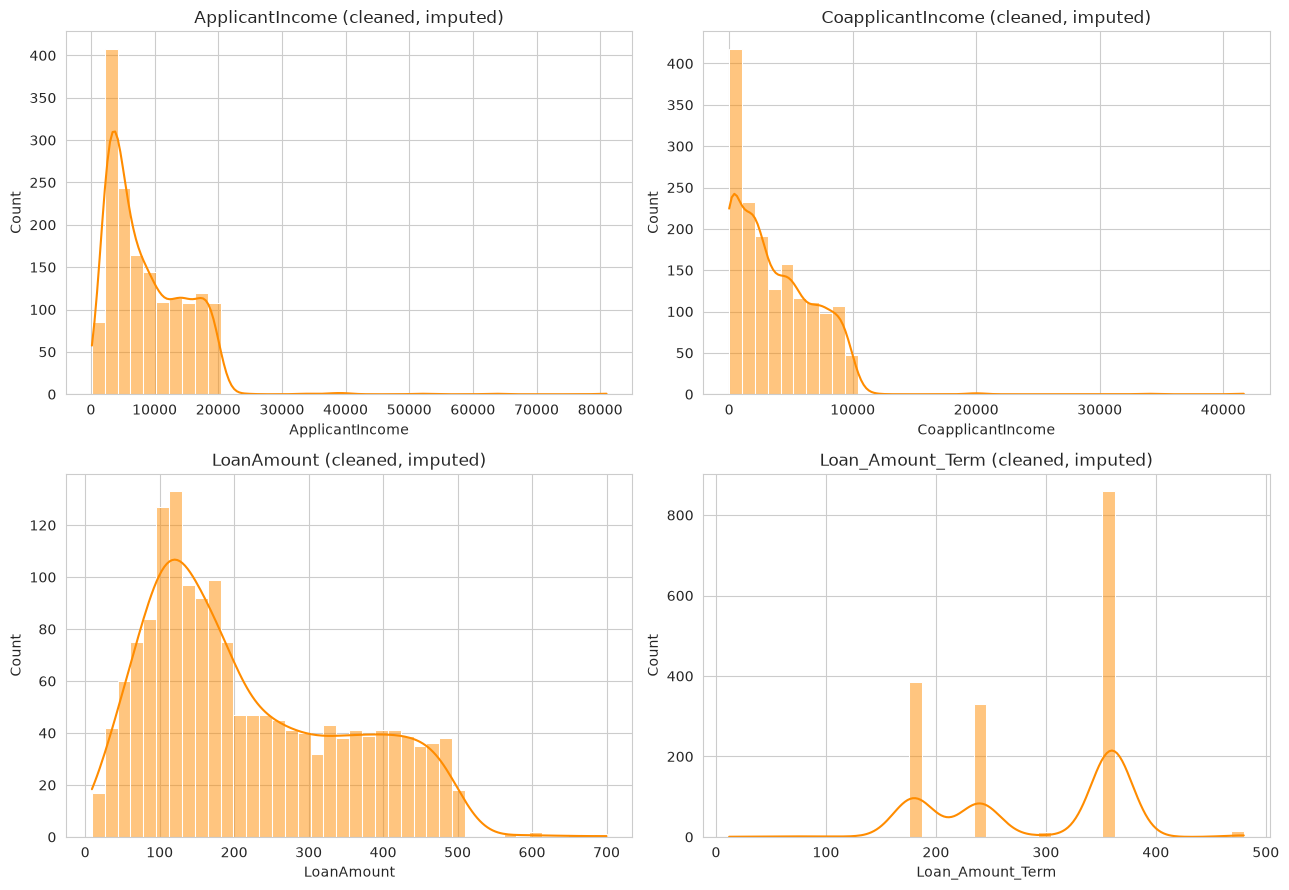

In [46]:
num_cols_l = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), num_cols_l):
    sns.histplot(loan_clean[col], bins=40, kde=True, ax=ax, color="darkorange")
    ax.set_title(f"{col} (cleaned, imputed)")
plt.tight_layout()
plt.show()

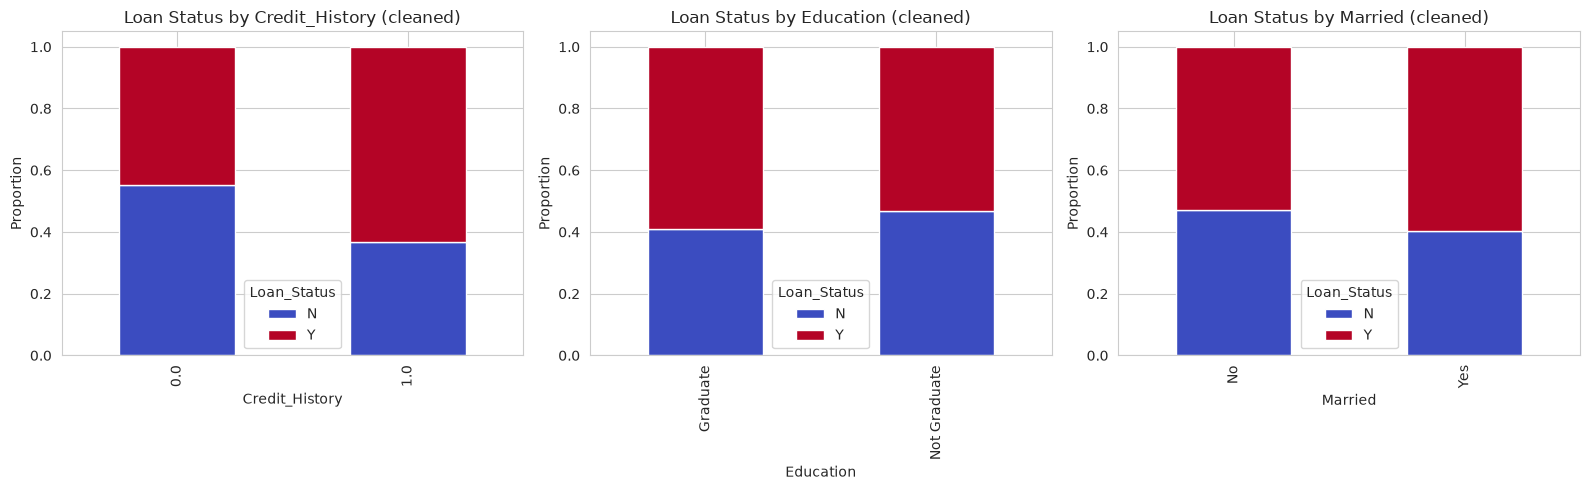

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Credit_History", "Education", "Married"]):
    ct = pd.crosstab(loan_clean[col], loan_clean["Loan_Status"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm")
    ax.set_title(f"Loan Status by {col} (cleaned)")
    ax.set_ylabel("Proportion")
plt.tight_layout()
plt.show()

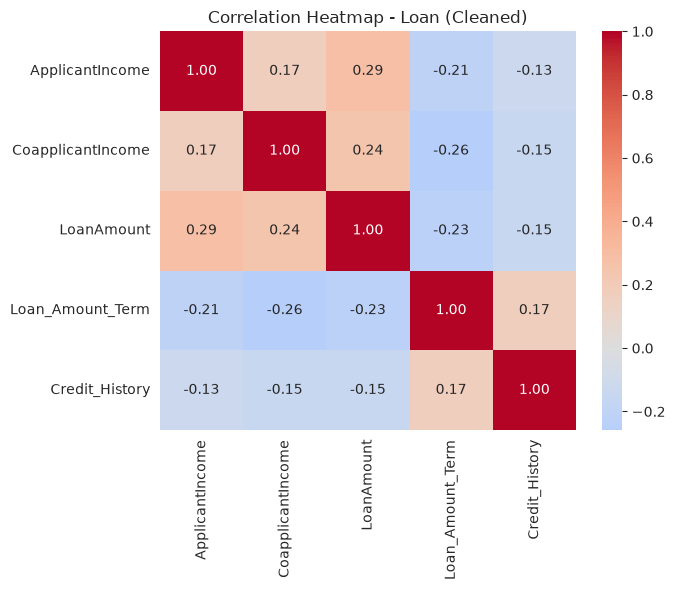

In [48]:
num_corr_l = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
plt.figure(figsize=(7, 6))
sns.heatmap(loan_clean[num_corr_l].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Loan (Cleaned)")
plt.tight_layout()
plt.show()

**Observations:** `LoanAmount`'s distribution is a little tighter around the median after imputing
missing values with it, as expected. `Credit_History`'s strong association with `Loan_Status` persists
after imputation — the relationship isn't an artifact of the missing rows. Since no duplicate rows were
found, the row count (1,614) is unchanged from the raw dataset — only values were imputed, no rows dropped.

---
# Summary

- **Adult Census Income**: ~48,842 records, mild class imbalance (~76% earn ≤50K). Key drivers of higher income
  include education level, hours worked per week, age, and marital status. `workclass`, `occupation`, and
  `native-country` contain missing values (encoded as `?`).
- **Hotel Booking Demand**: ~119,390 bookings across two hotel types. Roughly 37% of bookings are canceled overall,
  with City Hotel showing a notably higher cancellation rate than Resort Hotel. `company` and `agent` have heavy
  missingness (expected, as many bookings aren't made through an agent/company); `country` and `children` have
  minor missingness.
- **Loan Prediction**: ~1,614 records, target is imbalanced toward approvals (~69% "Y"). `Credit_History` is
  strongly associated with approval outcome. Several columns (`Credit_History`, `LoanAmount`, `Self_Employed`,
  `Gender`, `Dependents`) contain missing values that would need imputation before modeling.

**Cleaning outputs:** Section 4 documents and applies concrete cleaning decisions for each dataset and
exports the results as `adult_cleaned.csv`, `hotel_booking_cleaned.csv`, and `loan_train_cleaned.csv`,
ready for downstream modeling.